<a href="https://colab.research.google.com/github/cavalcantiju/visaocomp-2.4-memoria/blob/main/semana2_memoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

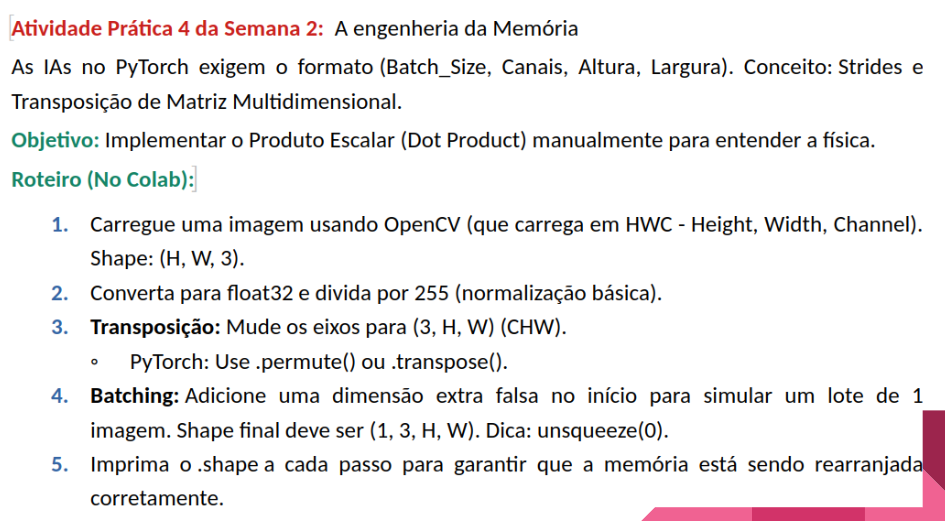

In [1]:
import cv2
import torch
import numpy as np

# 1. Carregar imagem com OpenCV (H, W, C)
img_bgr = cv2.imread('color.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"1. Shape Original (OpenCV): {img_rgb.shape}") # Ex: (512, 512, 3)

# 2. Converter para float32 e normalizar
img_tensor = torch.from_numpy(img_rgb).float() / 255.0

# 3. Transposição (H, W, C) -> (C, H, W)
# No PyTorch usamos o permute. A ordem dos eixos era 0, 1, 2. Queremos 2, 0, 1.
img_chw = img_tensor.permute(2, 0, 1)
print(f"3. Shape após Transposição (CHW): {img_chw.shape}")

# 4. Batching: Adicionar dimensão extra no início (1, C, H, W)
# O unsqueeze(0) cria uma dimensão na posição zero.
img_final = img_chw.unsqueeze(0)
print(f"4. Shape Final para a IA (B, C, H, W): {img_final.shape}")

# 5. Conferência final
print("-" * 30)
print(f"Tensor pronto para inferência!")
print(f"Dimensoes: {img_final.shape}")

1. Shape Original (OpenCV): (420, 510, 3)
3. Shape após Transposição (CHW): torch.Size([3, 420, 510])
4. Shape Final para a IA (B, C, H, W): torch.Size([1, 3, 420, 510])
------------------------------
Tensor pronto para inferência!
Dimensoes: torch.Size([1, 3, 420, 510])


o que a gente fez aqui foi o 'transporte' de dados da visão humana para a visão de máquina. Se você tentar jogar uma imagem direto do OpenCV em uma rede neural, o código vai quebrar.

Por que essas mudanças de formato são necessárias?

O Padrão HWC vs CHW: O OpenCV organiza os dados pixel por pixel (cada ponto tem R, G e B juntos). Mas as IAs modernas preferem processar 'planos' de cor. Elas querem ver primeiro toda a camada Vermelha, depois toda a Verde, e então a Azul. Por isso usamos o permute para mover os Canais para a frente.

A Dimensão 'Batch': Reparem que o shape final ficou com um 1 na frente. As Redes Neurais nunca processam 'uma imagem', elas processam 'lotes' (batches) de imagens para ganhar velocidade na GPU. Mesmo que você só tenha uma foto, você precisa fingir que tem um lote de tamanho 1 usando o unsqueeze.

Engenharia de Memória: O mais legal é que, assim como no reshape que vimos antes, o PyTorch tenta fazer essas mudanças sem copiar os dados de lugar na RAM, apenas mudando os Strides (o manual de instrução que diz como ler a memória).

Resumo da estrutura final:
[Lote, Canais, Altura, Largura]
É nessa língua que o PyTorch fala. Sem essa organização, o modelo não consegue aplicar os filtros de convolução corretamente!